# Exercise 1

## Import packages

In [94]:
import skimage.io as io
import skimage.color
import skimage.exposure
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv

## Task 1

Implementation of some basic vector and matrix calculations using NumPy.

Reference: https://numpy.org/doc/1.18/reference/index.html

Create the following vectors and matrix using numpy. They should use floating point as data type.
$$
a = \begin{bmatrix}
1 & 0 & 1 & 0 & 1
\end{bmatrix}
$$

$$
b = \begin{bmatrix}
1 & 2 & 3 & 4 & 5
\end{bmatrix}
$$

$$
M =\begin{bmatrix}
1 & 2 & 3\\
4 & 5 & 6\\
7 & 8 & 9\\
\end{bmatrix}
$$

Also define the following scalar value
$$k = 5.0$$

In [95]:
# TODO: Create vectors, matrix and scalar value
a=np.array([1,0,1,0,1])
b=np.array([1,2,3,4,5])
M=np.array([[1,2,3],
            [4,5,6],
            [7,8,9]])
k=5

print(f'a = {a}')
print(f'b = {b}')
print(f'M = {M}')
print(f'k = {k}')

a = [1 0 1 0 1]
b = [1 2 3 4 5]
M = [[1 2 3]
 [4 5 6]
 [7 8 9]]
k = 5


In [96]:
# TODO: Add vector a with vector b
add = a + b
np.testing.assert_allclose(add, np.array([2, 2, 4, 4, 6]))
print(f'a + b = {add}')

# TODO: Multiply vector a with scalar value k
mult = a*k
np.testing.assert_allclose(mult, np.array([5, 0, 5, 0, 5]))
print(f'k * a = {mult}')

# TODO: Dot product between a and b
dot = a@b
np.testing.assert_allclose(dot, 9.0)
print(f'<a, b> = {dot}')

# TODO: Create vector c by sclicing vector a in order to get [0, 1, 0]
c = a[1:4]
np.testing.assert_allclose(c, [0, 1, 0])
print(f'c = {c}')

# TODO: Multiply vector c with matrix M
cM_mult = c*M
np.testing.assert_allclose(cM_mult, [[0, 2, 0], [0, 5, 0], [0, 8, 0]])
print(f'c * M = {cM_mult}')

# TODO: Dot product between vector and matrix M     --which vector??
cM_dot = c@M
np.testing.assert_allclose(cM_dot, [4, 5, 6])
print(f'<c, M> = {cM_dot}')

# TODO: Use a numpy-helper function to create a vector d = [0, 1, 2 ..., 99]
d = np.linspace(0,99,100)

# TODO: Now use slicing with strides to reduce this vector to d_small = [40, 50, 60]
d_small = d[40:61:10]
np.testing.assert_allclose(d_small, [40, 50, 60])
print(f'd_small = {d_small}')

a + b = [2 2 4 4 6]
k * a = [5 0 5 0 5]
<a, b> = 9
c = [0 1 0]
c * M = [[0 2 0]
 [0 5 0]
 [0 8 0]]
<c, M> = [4 5 6]
d_small = [40. 50. 60.]


## Task 2

1. Load the image in ```./data/pepo.jpg``` from your disk and store it in a variable named ```image``` (use ```skimage.io```).
2. Store and print the shape of the image and the value range (min and max values).
3. Convert it to gray scale and save it in a variable named ```image_gray``` (use ```skimage.color```).
4. Store and print the shape of the grayscale image and the value range (min and max values).
5. Save the grayscale image back to disk in ```./data/pepo_gray.jpg``` (use ```skimage.io```).
6. Use Matplotlib to show the RGB and the grayscale image side by side.

Reference: https://scikit-image.org/docs/stable/index.html  
Reference: https://matplotlib.org/users/index.html  

In [97]:
# TODO: 1. Load the image in ./data/pepo.jpg from your disk and store it in a variable named image
image = io.imread("./data/pepo.jpg")

# TODO: 2. Store and print the shape of the image and the value range (min and max values)
print(f'RGB image shape: {image.shape}')
print(f'RGB image min: {image.min()}')
print(f'RGB image max: {image.max()}')

# TODO: 3. Convert it to gray scale and save it in a variable named image_gray
image_gray = io.imread("./data/pepo.jpg", as_gray=True)

# TODO: 4. Store and print the shape of the grayscale image and the value range (min and max values)
print(f'Grayscale image shape: {image_gray.shape}')
print(f'Grayscale image min: {image_gray.min()}')
print(f'Grayscale image max: {image_gray.max()}')

# TODO: 5. Save the grayscale image back to disk in ./data/pepo_gray.jpg
io.imsave("./data/pepo_gray.jpg",image_gray)



Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.


RGB image shape: (512, 512, 3)
RGB image min: 0
RGB image max: 255
Grayscale image shape: (512, 512)
Grayscale image min: 0.0008333333333333333
Grayscale image max: 1.0


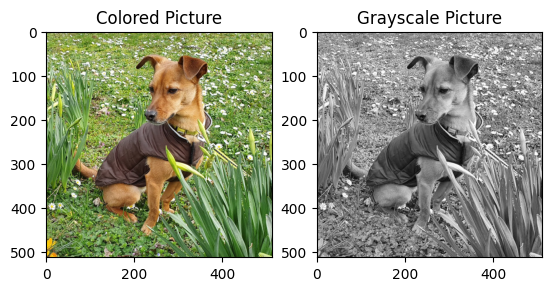

In [98]:
# TODO: 6. Use Matplotlib to show the RGB and the grayscale image side by side.
# Make sure that the gray image is displayed in gray.
fig, (ax1, ax2) = plt.subplots(1, 2)
img = plt.imread("./data/pepo.jpg")
img_gray = plt.imread("./data/pepo_gray.jpg")
ax1.imshow(img)
ax1.set_title("Colored Picture")
ax2.imshow(img_gray, cmap="gray")
ax2.set_title("Grayscale Picture")
plt.show()


## Task 3

Plot the color histogram of the rgb image.

Reference: https://matplotlib.org/users/index.html

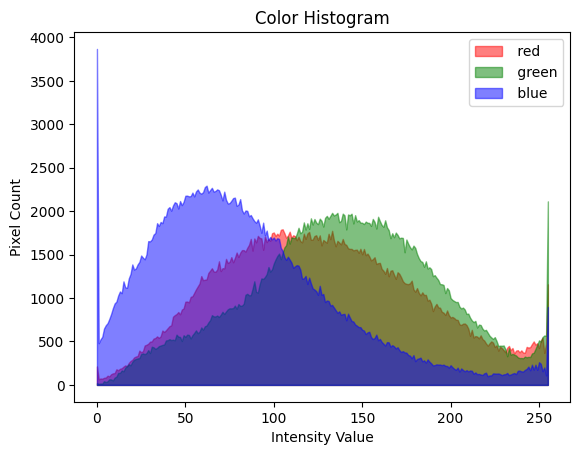

(512, 512, 3)

In [99]:
def plot_color_histogram(image):
    '''
    Plot the histogram of each color channel into a single plot.
    Take a look at the scikit-image submodule skimage.exposure

    image -- RGB image
    '''
    # TODO: implement this function
    colors=("red","green","blue")       
    for index, color in enumerate(colors):      #iterate through each color channel
        hist, bin_centers= skimage.exposure.histogram(image[:,:,index], nbins=256)
        plt.fill_between(bin_centers, hist, color=color, alpha=0.5,label=f" {color}")
        
    plt.title('Color Histogram')
    plt.xlabel('Intensity Value')
    plt.ylabel('Pixel Count')
    plt.legend()
    plt.show()
    pass
image=io.imread("./data/pepo.jpg")

plot_color_histogram(image)
image.shape

## Task 4

Convert the RGB image into the HSV color space. Rotate the colors in the HSV color space, convert it back to the RGB color space and plot it together with its histogram. For this task, you are only allowed to use NumPy.

More information about the HSV color space: https://en.wikipedia.org/wiki/HSL_and_HSV

In [100]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.stack((a,b),axis=1))
print(np.stack((a,b),axis=0))


[[1 4]
 [2 5]
 [3 6]]
[[1 2 3]
 [4 5 6]]


In [101]:
def rgb2hsv(rgb_image):
    '''
    Convert the rgb image into hsv color space and return it.

    image -- rgb image
    '''
    # TODO: implement function
    image_normalized=rgb_image/255
    Max=np.max(image_normalized,axis=2)     #compare each pixel with of one channel with the one in the other color channel
    Min=np.min(image_normalized,axis=2)
    chroma=Max-Min

    #color channels
    R= image_normalized[:,:,0]
    G= image_normalized[:,:,1]
    B= image_normalized[:,:,2]

    #hue
    hue=np.zeros_like(Max)      #create a zero matrix (255,255)

    #calculating the Hue. Instead of iterating through every single pixel using loops
    #use a mask:
    chroma_mask=chroma !=0  #returns a mask of the chroma, where non zero values are True (True,True, False etc.) 

    #channel masks:  #both conditions must hold
    R_mask=(Max == R) & chroma_mask     #only true if non zero and max value is red channel
    G_mask=(Max == G) & chroma_mask
    B_mask=(Max ==B) & chroma_mask

    #apply the formula for the hue
    hue[R_mask]=60*(((G[R_mask]-B[R_mask])/chroma[R_mask])%6)
    hue[G_mask]=60*(((B[G_mask]-R[G_mask])/chroma[G_mask])+2)
    hue[B_mask]=60*(((R[B_mask]-G[B_mask])/chroma[B_mask])+4)


    #Saturation
    Max_mask=Max !=0
    saturation=np.zeros_like(Max)       #zero grid
    saturation[Max_mask]=chroma[Max_mask]/Max[Max_mask] #only non zero values are inserted

    #Value
    value=Max
    
    #hsv
    hsv = np.stack([hue, saturation, value], axis=2)

    return hsv

def hsv2rgb(hsv_image):
    '''
    Convert the hsv image into rgb color space and return it.

    image -- rgb image
    '''
    # TODO: implement function
    hue=hsv_image[:,:,0]
    saturation=hsv_image[:,:,1]
    value=hsv_image[:,:,2]

    #compute Chroma:
    chroma=value*saturation

    #intermediate value X:
    hue_normalized=hue/60
    X=chroma*(1-np.abs(hue_normalized%2 -1))

    #create 6 masks:
    H01= (hue_normalized >= 0) & (hue_normalized < 1)
    H12= (hue_normalized >= 1) & (hue_normalized < 2)
    H23= (hue_normalized >= 2) & (hue_normalized < 3)
    H34= (hue_normalized >= 3) & (hue_normalized < 4)
    H45= (hue_normalized >= 4) & (hue_normalized < 5)
    H56= (hue_normalized >= 5) & (hue_normalized < 6)

    h,w=hue.shape
    rgb_raw=np.zeros((h,w,3))
    #red channels
    rgb_raw[:,:,0][H01]=chroma[H01]
    rgb_raw[:,:,0][H12]=X[H12]
    rgb_raw[:,:,0][H45]=X[H45]
    rgb_raw[:,:,0][H56]=chroma[H56]

    #green channels
    rgb_raw[:,:,1][H01]=X[H01]
    rgb_raw[:,:,1][H12]=chroma[H12]
    rgb_raw[:,:,1][H23]=chroma[H23]
    rgb_raw[:,:,1][H34]=X[H34]
    
    #blue channels
    rgb_raw[:,:,2][H23]=X[H23]
    rgb_raw[:,:,2][H34]=chroma[H34]
    rgb_raw[:,:,2][H45]=chroma[H45]
    rgb_raw[:,:,2][H56]=X[H56]

    #match value to counteract the shift
    match_val=value-chroma
    rgb=np.zeros((h,w,3))
    for i in range(3):
        rgb[:,:,i]=rgb_raw[:,:,i]+match_val

    rgb = (rgb * 255).clip(0, 255)

    return rgb.astype(np.uint8)



 Plot the HSV channels


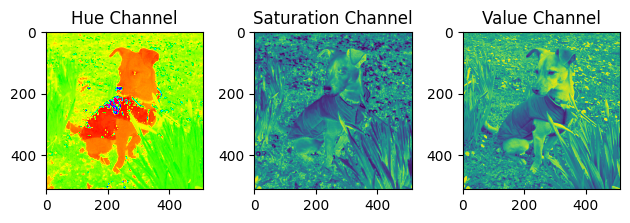

 plot the hue channel rotated by


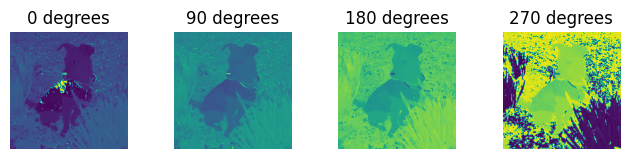

now plot the rotated HSV images back to rgb with the following degrees:


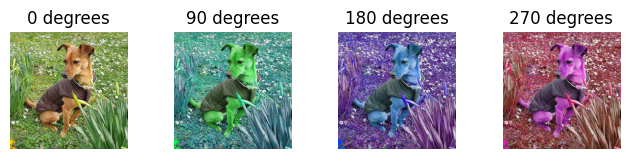

now plot the histograms of the rotated rgb images


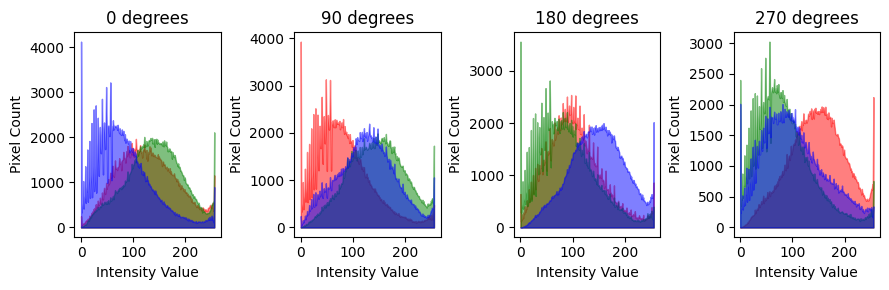

In [102]:
# Change the color space from rgb to hsv and plot it
image_hsv = rgb2hsv(image)
print(" Plot the HSV channels")
# TODO: plot image
hue=image_hsv[:,:,0]
saturation=image_hsv[:,:,1]
value=image_hsv[:,:,2]

fig, (hue_img, saturation_img,value_img)=plt.subplots(ncols=3)
hue_img.imshow(hue,cmap="hsv")
hue_img.set_title("Hue Channel")

saturation_img.imshow(saturation)
saturation_img.set_title("Saturation Channel")

value_img.imshow(value)
value_img.set_title("Value Channel")

fig.tight_layout()
plt.show()

# TODO: Rotate the colors in hsv color space
print(' plot the hue channel rotated by')

fig, axes = plt.subplots(1, 4)  # 1 row, 4 columns

for i in range(4):
    hue_rotated=(hue+i*90)%360
    axes[i].imshow(hue_rotated)
    axes[i].set_title(f"{i*90} degrees")
    axes[i].axis("off")
fig.tight_layout()
plt.subplots_adjust(wspace=0.4,hspace=0)
plt.show()

# TODO: Now, convert it back from HSV to RGB and plot it
fig, axes = plt.subplots(1, 4)  # 1 row, 4 columns
print("now plot the rotated HSV images back to rgb with the following degrees:")
for i in range(4):
    hue_rotated=(hue+i*90)%360
    hsv_image_rotated=np.stack([hue_rotated, saturation, value], axis=2)
    rgb_image_rotated=hsv2rgb(hsv_image_rotated)
    axes[i].imshow(rgb_image_rotated)
    axes[i].set_title(f"{i*90} degrees")
    axes[i].axis("off")
fig.tight_layout()
plt.subplots_adjust(wspace=0.4,hspace=0)
plt.show()



# TODO: Plot the color histogram of the inverted rgb image
fig, axes = plt.subplots(1, 4, figsize=(9, 3))  # 1 row, 4 columns
print("now plot the histograms of the rotated rgb images")
for i in range(4):
    hue_rotated=(hue+i*90)%360
    hsv_image_rotated=np.stack([hue_rotated, saturation, value], axis=2)
    rgb_image_rotated=hsv2rgb(hsv_image_rotated)
    colors=("red","green","blue")       
    for index, color in enumerate(colors):      #iterate through each color channel
        hist, bin_centers= skimage.exposure.histogram(rgb_image_rotated[:,:,index], nbins=256)
        axes[i].fill_between(bin_centers, hist, color=color, alpha=0.5,label=f" {color}")
    axes[i].set_title(f"{i*90} degrees")
    axes[i].set_xlabel('Intensity Value')
    axes[i].set_ylabel('Pixel Count')
fig.tight_layout()
plt.subplots_adjust(wspace=0.5,hspace=0)
plt.show()
